In [1]:
# Provides ways to work with large multidimensional arrays
import numpy as np 
# Allows for further data manipulation and analysis
import pandas as pd
# from pandas_datareader import data as web # Reads stock data 
import matplotlib.pyplot as plt # Plotting
import matplotlib.dates as mdates # Styling dates
%matplotlib inline

import time
from datetime import datetime, timezone
# import mplfinance as mpf # Matplotlib finance
import os
from os import listdir
from os.path import isfile, join
from pathlib import Path

import requests
import json
import csv

In [2]:
# Define path to files
PATH = "/Users/hialfonso/Banas/Section53_Finance/"
PATH = "C:/Udemy/2026-Python-EricBanas/Banas/Section53_Finance/redo/"

# Start date defaults
S_YEAR = 2025
S_MONTH = 1
S_DAY = 3
S_DATE_STR = f"{S_YEAR}-0{S_MONTH}-0{S_DAY}"
S_DATE_DATETIME = datetime(S_YEAR, S_MONTH, S_DAY)

# End date defaults
E_YEAR = 2025
E_MONTH = 12
E_DAY = 31
E_DATE_STR = f"{E_YEAR}-{E_MONTH}-{E_DAY}"
E_DATE_DATETIME = datetime(E_YEAR, E_MONTH, E_DAY)

missing_tickers = []
tickers_to_skip = ['FIT']
risk_free_rate = 0.0125 # Approximate 10 year bond rate



In [3]:
def get_df_from_csv(ticker):
    
    # Try to get the file and if it doesn't exist issue a warning
    try:

        if ticker not in tickers_to_skip:
            df = pd.read_csv(PATH + 'converted/' + ticker + '.csv')
            # df['date2'] = pd.DatetimeIndex(['date'])
            df = df.set_index(pd.to_datetime(df['date']))
            df.drop(columns=['date'], inplace=True)
            df = df.loc[S_DATE_STR:E_DATE_STR]
            return df
        else:
            return None
        # df = delete_unnamed_cols(df)
        
    except FileNotFoundError:
        missing_tickers.append(ticker)
        print(f"File for ticker {ticker} doesn't exist")
        return None
        

def merge_df_by_column_name(col_name, sdate, edate, *tickers):
    mult_df = pd.DataFrame()
    for x in tickers:
        df = get_df_from_csv(x)
        if df is not None:
            # df['Date'] = pd.to_datetime(df['date'])
            # mask = (df['Date'] >= sdate) & (df['Date'] <= edate)
            mult_df[x] = df.loc[sdate:edate][col_name]
        else:
            print (x + " not found")

    return mult_df

## Stock Portfolio

In [139]:
port_list = ["GNRC", "DXCM", "AMD", "NFLX", "COST", "TGT", "AES", "MSCI", 
             "NEM", "SBAC", "AMT"]

## Merge all Stock Price Data

In [140]:
mult_df = merge_df_by_column_name('close', S_DATE_STR, E_DATE_STR, *port_list)
mult_df

,GNRC,DXCM,AMD,NFLX,COST,TGT,AES,MSCI,NEM,SBAC,AMT
date,,,,,,,,,,,
2025-01-03,158.88,81.07,125.37,88.105,910.577931,128.743072,12.318871,591.608707,37.398948,196.380536,174.625452
2025-01-06,160.06,79.88,129.55,88.179,916.667790,132.061437,12.114022,586.867811,37.084919,193.587612,172.425416
2025-01-07,161.00,79.35,127.33,87.919,915.336564,132.023513,12.058154,581.625286,37.448015,190.629253,169.469716
2025-01-08,158.62,80.09,121.84,87.500,921.297274,131.046966,11.546031,592.346398,38.399917,194.346664,171.401921
2025-01-10,157.44,77.76,116.04,83.769,930.804607,134.270520,11.192201,566.281308,38.370477,187.583311,165.920962
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,140.81,67.42,215.04,93.640,870.670548,95.558136,13.796685,579.466311,104.518474,191.296747,171.402922
2025-12-26,140.56,67.57,214.99,94.470,872.158515,98.547731,13.905398,582.693593,105.566353,191.296747,172.981633
2025-12-29,138.48,67.47,215.61,94.150,866.656032,97.112329,13.964696,583.460570,99.608411,192.379371,174.090552


## Plot Growth of Investments over Total Dataset

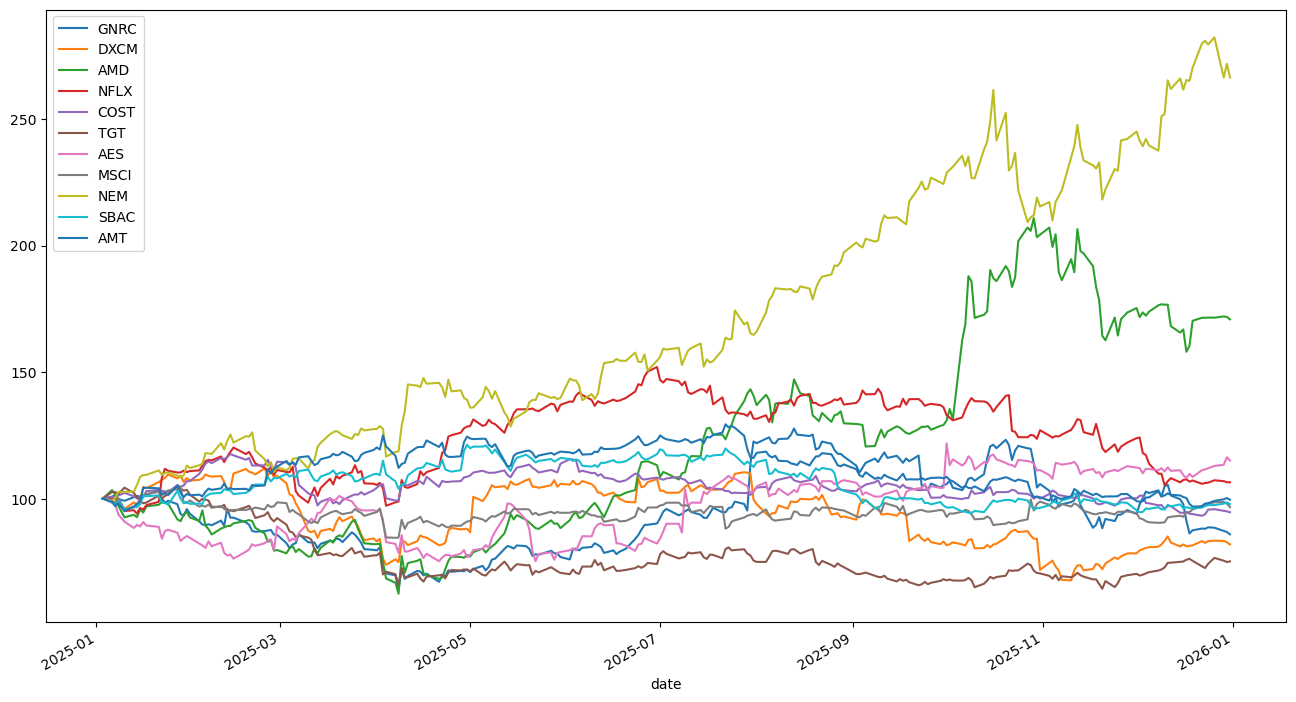

In [141]:
(mult_df / mult_df.iloc[0] * 100).plot(figsize=(16, 9))
plt.show()

## Mean Returns

Many finance models assume returns are approximately normally distributed. Log returns often behave better statistically than raw percent returns.

Used in:

Portfolio theory,
Black-Scholes,
Risk models,
Monte Carlo simulations

np.log() is used because it converts price changes into log returns, which are:

additive through time,
statistically convenient,
standard in quantitative finance,
useful for annualizing returns and volatility

Use log returns when asking:
What is expected return?
Volatility?
Correlations?
Statistical modeling?
Optimization?

In [167]:
returns = np.log(mult_df / mult_df.shift(1))
returns
mean_ret = returns.mean() * 252 # 252 average trading days per year
mean_ret

GNRC   -0.155242
DXCM   -0.203295
AMD     0.544090
NFLX    0.063212
COST   -0.056695
TGT    -0.290130
AES     0.142413
MSCI   -0.035178
NEM     0.995811
SBAC   -0.022282
AMT    -0.004621
dtype: float64

## Covariance

In [168]:
returns.cov() * 252

,GNRC,DXCM,AMD,NFLX,COST,TGT,AES,MSCI,NEM,SBAC,AMT
GNRC,0.216614,0.042492,0.116642,0.028163,0.012836,0.070384,0.061859,0.038964,0.020311,0.005056,0.004228
DXCM,0.042492,0.203901,0.078190,0.040512,0.023992,0.047518,0.022371,0.032899,0.014673,0.001253,0.000852
AMD,0.116642,0.078190,0.347264,0.072686,0.016097,0.061710,0.071491,0.049130,0.039854,-0.014533,-0.020763
NFLX,0.028163,0.040512,0.072686,0.117066,0.024602,0.011064,0.016247,0.029565,0.025044,-0.001174,-0.002561
COST,0.012836,0.023992,0.016097,0.024602,0.047262,0.019309,0.007186,0.019979,0.007532,0.010984,0.008599
TGT,0.070384,0.047518,0.061710,0.011064,0.019309,0.118050,0.044931,0.024595,-0.000564,0.003066,0.004248
AES,0.061859,0.022371,0.071491,0.016247,0.007186,0.044931,0.235854,0.024657,0.027208,0.013993,0.014168
MSCI,0.038964,0.032899,0.049130,0.029565,0.019979,0.024595,0.024657,0.078120,0.008727,0.011773,0.007491
NEM,0.020311,0.014673,0.039854,0.025044,0.007532,-0.000564,0.027208,0.008727,0.167138,0.018707,0.015618
SBAC,0.005056,0.001253,-0.014533,-0.001174,0.010984,0.003066,0.013993,0.011773,0.018707,0.061196,0.050774


## Correlation

In [169]:
returns.corr()

,GNRC,DXCM,AMD,NFLX,COST,TGT,AES,MSCI,NEM,SBAC,AMT
GNRC,1.000000,0.202188,0.425286,0.176854,0.126865,0.440145,0.273677,0.299532,0.106744,0.043913,0.036951
DXCM,0.202188,1.000000,0.293839,0.262217,0.244403,0.306275,0.102015,0.260671,0.079483,0.011216,0.007679
AMD,0.425286,0.293839,1.000000,0.360499,0.125649,0.304786,0.249805,0.298291,0.165428,-0.099689,-0.143326
NFLX,0.176854,0.262217,0.360499,1.000000,0.330750,0.094115,0.097777,0.309158,0.179040,-0.013870,-0.030452
COST,0.126865,0.244403,0.125649,0.330750,1.000000,0.258501,0.068064,0.328802,0.084750,0.204240,0.160889
TGT,0.440145,0.306275,0.304786,0.094115,0.258501,1.000000,0.269269,0.256115,-0.004019,0.036077,0.050287
AES,0.273677,0.102015,0.249805,0.097777,0.068064,0.269269,1.000000,0.181652,0.137038,0.116471,0.118675
MSCI,0.299532,0.260671,0.298291,0.309158,0.328802,0.256115,0.181652,1.000000,0.076376,0.170271,0.109020
NEM,0.106744,0.079483,0.165428,0.179040,0.084750,-0.004019,0.137038,0.076376,1.000000,0.184972,0.155400
SBAC,0.043913,0.011216,-0.099689,-0.013870,0.204240,0.036077,0.116471,0.170271,0.184972,1.000000,0.834900


## Generate Random Weights Equal to 1

In [170]:
weights = np.random.random(11)
weights /= np.sum(weights)
print('Weights: ', weights)
print('Total Weight: ', np.sum(weights))


Weights:  [0.08597183 0.03652897 0.0155893  0.12951332 0.11998355 0.09737717
 0.09001074 0.07783271 0.09492374 0.1224669  0.12980176]
Total Weight:  1.0


## Calculating Return of Portfolio

In [80]:
np.sum(weights * returns.mean()) * 252

np.float64(0.38367702543023985)

## Calculating Volatility (Risk)

In [81]:
np.sqrt(np.dot(weights.T, np.dot(returns.cov() * 252, weights)))

# port_var = np.dot(wts.T, np.dot(mult_df.cov() * 756, wts))
# np.dot(weights.T, np.dot(df.cov() * days, weights))


np.float64(0.2386042665261502)

## Analyzing Returns & Risks of 10000 Combinations

In [171]:
p_ret = []
p_vol = []
p_SR = []
p_wt = []

for x in range(10000):
    p_weights = np.random.random(11)
    p_weights /= np.sum(p_weights)

    ret_1 = np.sum(p_weights * returns.mean()) * 252
    p_ret.append(ret_1)

    vol_1 = np.sqrt(np.dot(p_weights.T, np.dot(returns.cov() * 252, p_weights)))
    p_vol.append(vol_1)

    SR_1 = (ret_1 - risk_free_rate) / vol_1
    p_SR.append(SR_1)

    p_wt.append(p_weights)

# Convert to Numpy arrays
p_ret = np.array(p_ret)
p_vol = np.array(p_vol)
p_SR = np.array(p_SR)
p_wt = np.array(p_wt)

p_ret, p_vol, p_SR, p_wt


(array([0.18201599, 0.0879278 , 0.0816247 , ..., 0.01443516, 0.02508367,
        0.05103154]),
 array([0.22101323, 0.1820173 , 0.21143569, ..., 0.2049783 , 0.18094735,
        0.17342825]),
 array([0.76699474, 0.41439907, 0.32693015, ..., 0.00944083, 0.06954326,
        0.2221757 ]),
 array([[0.08240086, 0.04966142, 0.17544568, ..., 0.1398829 , 0.02573141,
         0.10363622],
        [0.14858133, 0.01935087, 0.01979518, ..., 0.13479723, 0.16219641,
         0.06628531],
        [0.03028266, 0.18516332, 0.13285441, ..., 0.05511573, 0.16695878,
         0.01726739],
        ...,
        [0.10511075, 0.06350233, 0.0418136 , ..., 0.03377319, 0.16943652,
         0.01177231],
        [0.03646656, 0.1007744 , 0.05298017, ..., 0.02087124, 0.11646446,
         0.09213606],
        [0.05774296, 0.10873335, 0.03603456, ..., 0.09951102, 0.10393126,
         0.11176374]]))

In [88]:
p_ret, p_vol, p_SR, p_wt

(array([0.3271821 , 0.38497002, 0.37789431, ..., 0.41353399, 0.34715234,
        0.35304709]),
 array([0.21391416, 0.23699053, 0.24756162, ..., 0.24942149, 0.22873282,
        0.24946774]),
 array([1.47106718, 1.57166623, 1.47597316, ..., 1.60785663, 1.46307094,
        1.36509472]),
 array([[0.13965542, 0.0479154 , 0.03723014, ..., 0.13781811, 0.06287155,
         0.14862128],
        [0.19273985, 0.08147849, 0.07557118, ..., 0.06213996, 0.10777813,
         0.01954138],
        [0.18063021, 0.00145199, 0.17887865, ..., 0.05690203, 0.02234408,
         0.19431846],
        ...,
        [0.18005666, 0.16653136, 0.10324522, ..., 0.00278503, 0.09732417,
         0.05242362],
        [0.00703458, 0.09424954, 0.12438323, ..., 0.10363608, 0.19020566,
         0.02507279],
        [0.04139828, 0.06767285, 0.13997761, ..., 0.21211976, 0.05238041,
         0.04175123]]))

## Plotting the Efficient Frontier

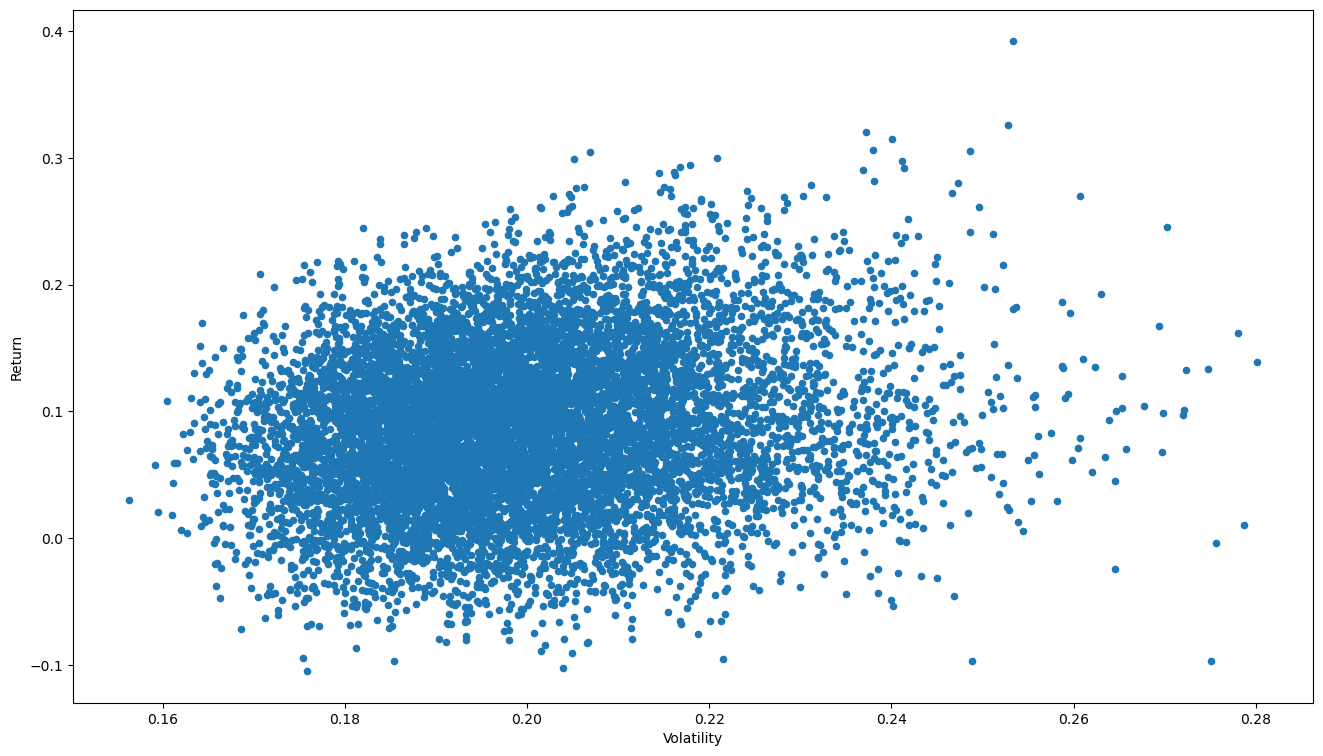

In [173]:
# Create a dataframe with returns and volatility
ports = pd.DataFrame({'Return': p_ret, 'Volatility': p_vol})

ports.plot(x='Volatility', y='Return', kind='scatter', figsize=(16, 9))
plt.show()

## Sharpe Ratio

*People want to maximize returns while avoiding as much risk as possible. William Sharpe created the Sharpe Ratio to find the portfolio that provides the best return for the lowest amount of risk.

Sharpe Ratio = \frac{r_i - r_f}{\sigma_i}
 
 Risk Free Rate = r_f

 Rate of Return of the stock = r_i

 Standard Deviation of the Stock = sigma_i

As return increases so does the Sharpe Ratio, but as Standard Deviation increase the Sharpe Ration decreases.*

In [187]:
# Return the index of the largest Sharpe Ratio
SR_idx = np.argmax(p_SR)

print ("Max Sharpe Ratio: ", p_wt[SR_idx])

# Find the ideal portfolio weighting at that index
i = 0
while i < 11:
    print("Stock : %s : %2.2f" % (port_list[i], (p_wt[SR_idx][i] * 100)))
    i += 1
    
# Find volatility of that portfolio
print("\nVolatility :", p_vol[SR_idx])
      
# Find return of that portfolio
print("Return :", p_ret[SR_idx])


# pd.DataFrame({'sharpe': p_SR}).sort_values(by=['sharpe'], ascending=False)
# np.argmax(p_SR)

Max Sharpe Ratio:  [0.01528077 0.03253548 0.2701225  0.162636   0.01712155 0.01624363
 0.06644329 0.01326444 0.24373482 0.08457    0.07804751]
Stock : GNRC : 1.53
Stock : DXCM : 3.25
Stock : AMD : 27.01
Stock : NFLX : 16.26
Stock : COST : 1.71
Stock : TGT : 1.62
Stock : AES : 6.64
Stock : MSCI : 1.33
Stock : NEM : 24.37
Stock : SBAC : 8.46
Stock : AMT : 7.80

Volatility : 0.25336335753195377
Return : 0.3920463234469043


,sharpe
9628,1.498032
4094,1.411246
9763,1.396827
7194,1.300503
5504,1.298165
...,...
1707,-0.548754
2028,-0.565524
8334,-0.588849
2337,-0.610894
